# 23_02 다중센서 패턴 분석

In [78]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


## 실습 1. 시간 인덱싱과 슬라이싱
### 목표
글자 날짜를 시간 형식으로 바꿔 인덱스로 올리고 날짜로 구간 자르기
### 단계
- 시각 열의 자료형을 확인하고 시간 형식으로 변환
- 시간 열을 인덱스로 올리기
- 하루·기간을 날짜로 잘라 행 수 확인
### 예상 결과
자료형이 시간으로 바뀌고, 하루 24행·사흘 72행

In [79]:
# 실습 1 코드
TS = '23_cmapss_unit1_timestamp.csv'

ts = pd.read_csv(TS)
ts['timestamp'] = pd.to_datetime(ts['timestamp'])
ts = ts.set_index('timestamp')
# ts.info()
# ts.head()

print(len(ts.loc['2024-01-06']))
print(len(ts.loc['2024-01-05':'2024-01-06']))


24
48


## 실습 2. 리샘플링 집계와 시간 이동통계
### 목표
시간 단위로 리샘플링해 대표값을 구하고 일별 이동평균으로 추세를 보기
### 단계
- 하루 단위 평균과 6시간 단위 평균을 각각 구하기
- 각 결과의 개수로 단위 차이를 확인
- 일별 평균에 이동평균을 걸어 추세를 매끄럽게
### 예상 결과
하루 평균 8개·6시간 평균 32개, 일별 값이 상승 추세

In [80]:
# 실습 2 코드
daily = ts['sensor_7'].resample('1D').mean()
print('하루단위 평균 : ', daily.round(2).head())

sixhours = ts['sensor_7'].resample('6h').mean()
print('6시간 평균 : ', sixhours.round(2).head())

daily_ma = daily.rolling(3).mean()
print('일별 평균에 이동평균 계산: ', daily_ma)

하루단위 평균 :  timestamp
2024-01-01    553.99
2024-01-02    553.77
2024-01-03    552.60
2024-01-04    551.69
2024-01-05    550.16
Freq: D, Name: sensor_7, dtype: float64
6시간 평균 :  timestamp
2024-01-01 00:00:00    554.05
2024-01-01 06:00:00    554.17
2024-01-01 12:00:00    553.96
2024-01-01 18:00:00    553.77
2024-01-02 00:00:00    554.19
Freq: 6h, Name: sensor_7, dtype: float64
일별 평균에 이동평균 계산:  timestamp
2024-01-01           NaN
2024-01-02           NaN
2024-01-03    553.452639
2024-01-04    552.687917
2024-01-05    551.483611
2024-01-06    550.026944
2024-01-07    548.084444
2024-01-08    545.885417
Freq: D, Name: sensor_7, dtype: float64


## 실습 3. 다중센서 정규화와 겹쳐 비교
### 목표
여러 센서를 0~1로 정규화해 같은 눈금에서 함께 비교
### 단계
· 세 센서를 최소·최대 기준으로 0~1로 정규화
· 정규화 후 최솟값·최댓값이 0과 1인지 확인
· 이동평균을 걸어 겹쳐 그릴 준비
### 예상 결과
각 센서의 최솟값 0·최댓값 1로 눈금이 맞춰짐

In [86]:
# 실습 3 코드
df = pd.read_csv('23_cmapss_fd001_sample.csv')
# df.head()
u2 = df[df['unit_number'] == 2].copy().reset_index(drop=True)
# u2.head()
# 특정 컬럼 선택
cols = ['sensor_3', 'sensor_7', 'sensor_15']
# 정규화
norm = (u2[cols] - u2[cols].min()) / (u2[cols].max() - u2[cols].min())
print(norm.min().tolist(), norm.max().tolist()) 
# norm.describe()

# 정규화 결과에 이동평균을 계산해서 더 평탄화된 결과를 그래프로 그릴 것임
norm_ma = norm.rolling(window=10).mean()
norm_ma.tail()

[0.0, 0.0, 0.0] [1.0, 1.0, 1.0]


,sensor_3,sensor_7,sensor_15
282,0.594223,0.265352,0.670909
283,0.666187,0.256870,0.670909
284,0.665450,0.272103,0.674545
285,0.657412,0.282139,0.650909
286,0.690954,0.241995,0.623636


## 실습 4. 다중센서 변화 폭 비교
### 목표
정규화한 여러 센서의 초반·후반 값을 비교해 변화 폭이 큰 센서를 찾기
### 단계
- 여섯 센서를 정규화하고 이동평균을 걸기
- 각 센서의 초반과 후반 평균을 구하기
- 초반·후반 차이로 변화 폭이 큰 감시 센서 선별
### 예상 결과
sensor_2는 크게 상승, sensor_7은 하락 — 변화 폭 큰 센서 부각

In [91]:
# 실습 4 코드
sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
# 정규화
n6 = (u2[sensors] - u2[sensors].min()) / (u2[sensors].max() - u2[sensors].min())
# n6.head()

# 정규화 결과의 이동평균
n6ma = n6.rolling(window=10).mean()
# n6ma.tail()

for c in ['sensor_3', 'sensor_7', 'sensor_15']:
    early = n6ma[c].iloc[10:40].mean()
    last = n6ma[c].iloc[150:].mean()
    print(c, round(early, 2), round(last, 2), round(last - early, 2))

sensor_3 0.17 0.45 0.28
sensor_7 0.9 0.49 -0.41
sensor_15 0.16 0.48 0.31


## 실습 5. 다중센서 상관 heatmap
### 목표
여러 센서의 상관행렬을 구해 heatmap으로 함께 움직이는 센서를 파악
### 단계
- 여섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 진한 칸으로 강한 양·음 관계를 읽기
### 예상 결과
sensor_2와 sensor_7이 강한 음(-0.96), sensor_2와 sensor_11이 양(0.84)


s2-s15: 0.81 s3-s11: 0.7


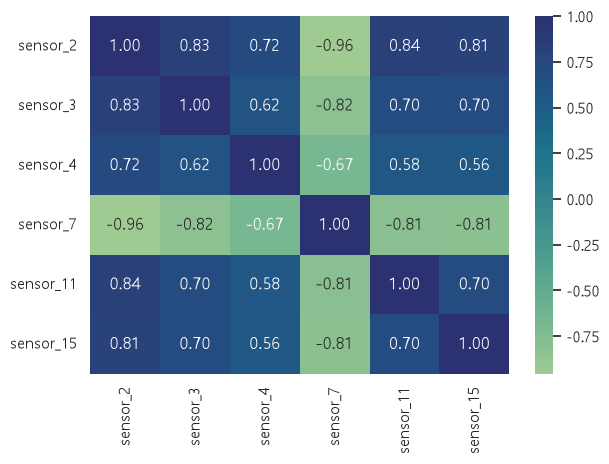

In [ ]:
# 실습 5 코드
corr = u2[sensors].corr()
# print('s2-s15:', round(corr.loc['sensor_2', 'sensor_15'], 2),
#       's3-s11:', round(corr.loc['sensor_3', 'sensor_11'], 2))   # 0.81 / 0.7

sns.heatmap(corr, annot=True, cmap='crest', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

## 실습 6. 상관 높은 센서쌍 추출
### 목표
상관행렬에서 대각선을 빼고 가장 강한 음·양의 센서쌍을 추출
### 단계
- 상관행렬에서 자기 자신 대각선을 제외
- 센서쌍을 상관값 순으로 정렬
- 가장 강한 음의 쌍과 양의 쌍을 확인
### 예상 결과
음의 최강쌍 sensor_2·sensor_7(-0.955), 양의 최강쌍 sensor_2·sensor_11(0.839)

In [ ]:
# 실습 6 코드 - 참고
pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
pairs = pairs[pairs.index.map(lambda x: x[0] < x[1])].sort_values()

print('음:', pairs.index[0], round(pairs.iloc[0], 3))    # ('sensor_2','sensor_7') -0.955
print('양:', pairs.index[-1], round(pairs.iloc[-1], 3))   # ('sensor_11','sensor_2') 0.839

음: ('sensor_2', 'sensor_7') -0.955
양: ('sensor_11', 'sensor_2') 0.839


## 실습 7. 종합 통합 분석
### 목표
이동통계·변화점을 계산하고 구간별로 나눠 이상 의심 구간을 도출
### 단계
- 이동평균·이동표준편차·변화점을 한 번에 계산
- 초반·후반 변동성과 변화점 개수를 요약
- 회차 구간별 변동성·변화점으로 이상 의심 구간 찾기
### 예상 결과
후반 변동성이 커지고 변화점 19개, 216~288 구간에 집중

In [101]:
s = u2['sensor_2']

u2['ma'] = s.rolling(10).mean()
u2['std'] = s.rolling(10).std()

resid = s - u2['ma']
u2['chg'] = resid.abs() > 2 * resid.std()

print('변동성 초반/후반:', round(u2['std'].iloc[10:50].mean(), 3), round(u2['std'].iloc[150:].mean(), 3))  # 0.319 / 0.516
print('변화점:', int(u2['chg'].sum()))            # 19

for lo, hi in ((0, 72), (72, 144), (144, 216), (216, 288)):
    seg = u2[(u2.time_cycles > lo) & (u2.time_cycles <= hi)]
    print(f'  {lo}~{hi}: 변동성 {seg["std"].mean():.3f}, 변화점 {int(seg["chg"].sum())}개')

변동성 초반/후반: 0.319 0.516
변화점: 19
  0~72: 변동성 0.304, 변화점 0개
  72~144: 변동성 0.311, 변화점 1개
  144~216: 변동성 0.295, 변화점 0개
  216~288: 변동성 0.723, 변화점 18개
